# Fase 1 — Exploración y Limpieza de Datos
**Proyecto Final — Gestión de Datos (UAX 2025/2026)**

| | |
|---|---|
| **Base de datos** | `saleshealth` (PostgreSQL 18) |
| **Conexión** | localhost:5432 |
| **Tablas** | 17 tablas operacionales |

**Objetivo:** Explorar en profundidad las 17 tablas de la base de datos operacional, detectar todos los problemas de calidad existentes y aplicar las correcciones necesarias — sin eliminar ningún cliente bajo ningún concepto.

---

## Índice
- [Sección 0 — Configuración y conexión](#seccion-0)
- [Sección 1 — Vista general de la base de datos](#seccion-1)
- [Sección 2 — Exploración tabla por tabla](#seccion-2)
- [Sección 3 — Análisis de calidad de datos](#seccion-3)
- [Sección 4 — Inventario de problemas detectados](#seccion-4)
- [Sección 5 — Correcciones](#seccion-5)
- [Sección 6 — Verificación post-limpieza](#seccion-6)
- [Sección 7 — Resumen y conclusiones](#seccion-7)

---
<a id='seccion-0'></a>
## Sección 0 — Configuración y conexión

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

PROJECT_ROOT = Path(r'C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd')
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Librerias importadas correctamente.')
print(f'Figuras en: {FIGURES_DIR}')

Librerias importadas correctamente.
Figuras en: C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd\reports\figures


In [2]:
# ── Conexión con SQLAlchemy ───────────────────────────────────────────────────
DB_USER     = 'postgres'
DB_PASSWORD = 'pimpum.postgre'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'saleshealth'

DATABASE_URL = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    result  = conn.execute(text('SELECT version()'))
    version = result.fetchone()[0]

print('Conexion establecida correctamente.')
print(f'   PostgreSQL: {version.split(",")[0]}')

Conexion establecida correctamente.
   PostgreSQL: PostgreSQL 18.3 on x86_64-windows


In [3]:
# ── Funciones helper ──────────────────────────────────────────────────────────
def query(sql: str, params: dict = None) -> pd.DataFrame:
    """Ejecuta una SELECT y devuelve el resultado como DataFrame."""
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn, params=params)


def execute(sql: str, params: dict = None) -> int:
    """Ejecuta un INSERT/UPDATE/DELETE. Devuelve el numero de filas afectadas."""
    with engine.begin() as conn:
        result = conn.execute(text(sql), params or {})
        return result.rowcount


def tabla_info(nombre_tabla: str) -> pd.DataFrame:
    """Devuelve la estructura (columnas, tipos, nulos) de una tabla."""
    sql = """
        SELECT column_name AS columna, data_type AS tipo,
               is_nullable AS permite_nulos, column_default AS valor_defecto
        FROM information_schema.columns
        WHERE table_schema = 'public' AND table_name = :tabla
        ORDER BY ordinal_position
    """
    return query(sql, {'tabla': nombre_tabla})


def nulos_tabla(nombre_tabla: str) -> pd.DataFrame:
    """Cuenta nulos por columna en una tabla dada."""
    columnas = query(
        "SELECT column_name FROM information_schema.columns "
        "WHERE table_schema='public' AND table_name=:t ORDER BY ordinal_position",
        {'t': nombre_tabla}
    )['column_name'].tolist()
    partes    = [f'COUNT(*) FILTER (WHERE "{c}" IS NULL) AS "{c}"' for c in columnas]
    resultado = query(f"SELECT {', '.join(partes)} FROM {nombre_tabla}")
    total     = query(f"SELECT COUNT(*) AS total FROM {nombre_tabla}")['total'].iloc[0]
    df        = resultado.T.reset_index()
    df.columns = ['columna', 'nulos']
    df['total']     = total
    df['pct_nulos'] = (df['nulos'] / total * 100).round(2)
    return df[df['nulos'] > 0].sort_values('nulos', ascending=False)


print('Funciones helper definidas: query(), execute(), tabla_info(), nulos_tabla()')

Funciones helper definidas: query(), execute(), tabla_info(), nulos_tabla()


In [4]:
# ── Constantes globales del proyecto ─────────────────────────────────────────
PALETA = {
    'ERP'       : '#2C6FBF',
    'CRM'       : '#27A06B',
    'Logistica' : '#E07B2A',
    'Postventa' : '#8B4BB8'
}

SISTEMAS = {
    'ERP'       : ['product', 'central_product', 'brand', 'category',
                   'sale', 'sale_item', 'offer', 'product_offer', 'store', 'inventory'],
    'CRM'       : ['customer', 'city_zone'],
    'Logistica' : ['warehouse', 'warehouse_location', 'central_inventory'],
    'Postventa' : ['return_item', 'return_reason']
}

# Verificacion de las 17 tablas
TABLAS_ESPERADAS = {
    'brand', 'category', 'central_inventory', 'central_product',
    'city_zone', 'customer', 'inventory', 'offer', 'product',
    'product_offer', 'return_item', 'return_reason', 'sale',
    'sale_item', 'store', 'warehouse', 'warehouse_location'
}
tablas_bd = set(
    query("SELECT table_name FROM information_schema.tables WHERE table_schema='public'")['table_name']
)
faltantes = TABLAS_ESPERADAS - tablas_bd
extras    = tablas_bd - TABLAS_ESPERADAS

print(f'Tablas esperadas : {len(TABLAS_ESPERADAS)}')
print(f'Tablas en BD     : {len(tablas_bd)}')
if not faltantes and not extras:
    print('\nTodo correcto - las 17 tablas esperadas estan presentes.')
else:
    if faltantes: print(f'\nTablas faltantes : {faltantes}')
    if extras:    print(f'Tablas extra     : {extras}')

Tablas esperadas : 17
Tablas en BD     : 17

Todo correcto - las 17 tablas esperadas estan presentes.


---
<a id='seccion-1'></a>
## Sección 1 — Vista general de la base de datos

### 1.1 — Conteo de registros por tabla

In [5]:
# ── 1.1 Conteo de registros por tabla ────────────────────────────────────────
sql_conteo = """
    SELECT 'brand' AS tabla, COUNT(*) AS registros FROM brand
    UNION ALL SELECT 'category', COUNT(*) FROM category
    UNION ALL SELECT 'central_inventory', COUNT(*) FROM central_inventory
    UNION ALL SELECT 'central_product', COUNT(*) FROM central_product
    UNION ALL SELECT 'city_zone', COUNT(*) FROM city_zone
    UNION ALL SELECT 'customer', COUNT(*) FROM customer
    UNION ALL SELECT 'inventory', COUNT(*) FROM inventory
    UNION ALL SELECT 'offer', COUNT(*) FROM offer
    UNION ALL SELECT 'product', COUNT(*) FROM product
    UNION ALL SELECT 'product_offer', COUNT(*) FROM product_offer
    UNION ALL SELECT 'return_item', COUNT(*) FROM return_item
    UNION ALL SELECT 'return_reason', COUNT(*) FROM return_reason
    UNION ALL SELECT 'sale', COUNT(*) FROM sale
    UNION ALL SELECT 'sale_item', COUNT(*) FROM sale_item
    UNION ALL SELECT 'store', COUNT(*) FROM store
    UNION ALL SELECT 'warehouse', COUNT(*) FROM warehouse
    UNION ALL SELECT 'warehouse_location', COUNT(*) FROM warehouse_location
    ORDER BY registros DESC
"""
df_conteo = query(sql_conteo)

display(df_conteo.style
    .format({'registros': '{:,.0f}'})
    .set_caption('Registros por tabla - saleshealth')
)

print(f"\nTotal de registros en la BD: {df_conteo['registros'].sum():,.0f}")

,tabla,registros
0,sale_item,"42,555"
1,sale,"20,000"
2,customer,"5,750"
3,return_item,"2,330"
4,inventory,"1,000"
5,product,50
6,central_product,50
7,central_inventory,49
8,city_zone,42
9,warehouse_location,40



Total de registros en la BD: 71,935


In [6]:
# ── Print: volumen de registros por tabla ─────────────────────────────────────
color_por_tabla = {t: s for s, ts in SISTEMAS.items() for t in ts}
total_bd        = df_conteo['registros'].sum()

print('=' * 58)
print(f'  VOLUMEN DE REGISTROS POR TABLA — saleshealth')
print(f'  {len(df_conteo)} tablas  |  {total_bd:,.0f} registros totales')
print('=' * 58)
print(f'  {"TABLA":<22} {"SISTEMA":<12} {"REGISTROS":>10}  {"% TOTAL":>8}')
print('-' * 58)

for _, row in df_conteo.iterrows():
    sistema = color_por_tabla.get(row['tabla'], '?')
    pct     = row['registros'] / total_bd * 100
    print(f'  {row["tabla"]:<22} {sistema:<12} {row["registros"]:>10,.0f}  {pct:>7.2f}%')

print('=' * 58)
print(f'  {"TOTAL":<22} {"":12} {total_bd:>10,.0f}  {"100.00%":>8}')
print('=' * 58)

  VOLUMEN DE REGISTROS POR TABLA — saleshealth
  17 tablas  |  71,935 registros totales
  TABLA                  SISTEMA       REGISTROS   % TOTAL
----------------------------------------------------------
  sale_item              ERP              42,555    59.16%
  sale                   ERP              20,000    27.80%
  customer               CRM               5,750     7.99%
  return_item            Postventa         2,330     3.24%
  inventory              ERP               1,000     1.39%
  product                ERP                  50     0.07%
  central_product        ERP                  50     0.07%
  central_inventory      Logistica            49     0.07%
  city_zone              CRM                  42     0.06%
  warehouse_location     Logistica            40     0.06%
  brand                  ERP                  29     0.04%
  store                  ERP                  20     0.03%
  product_offer          ERP                   6     0.01%
  category               ER

### 1.2 — Estructura y tipos de datos por tabla

In [7]:
# ── 1.2 Estructura completa de todas las tablas ───────────────────────────────
sql_estructura = """
    SELECT
        c.table_name                                        AS tabla,
        c.ordinal_position                                  AS pos,
        c.column_name                                       AS columna,
        c.data_type                                         AS tipo,
        c.is_nullable                                       AS nulos,
        CASE WHEN pk.column_name IS NOT NULL THEN 'PK' END  AS pk,
        CASE WHEN fk.column_name IS NOT NULL THEN 'FK' END  AS fk
    FROM information_schema.columns c
    LEFT JOIN (
        SELECT ku.table_name, ku.column_name
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage ku ON tc.constraint_name = ku.constraint_name
        WHERE tc.constraint_type = 'PRIMARY KEY' AND tc.table_schema = 'public'
    ) pk ON pk.table_name = c.table_name AND pk.column_name = c.column_name
    LEFT JOIN (
        SELECT ku.table_name, ku.column_name
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage ku ON tc.constraint_name = ku.constraint_name
        WHERE tc.constraint_type = 'FOREIGN KEY' AND tc.table_schema = 'public'
    ) fk ON fk.table_name = c.table_name AND fk.column_name = c.column_name
    WHERE c.table_schema = 'public'
    ORDER BY c.table_name, c.ordinal_position
"""
df_estructura = query(sql_estructura)

resumen = df_estructura.groupby('tabla').agg(
    columnas = ('columna', 'count'),
    tiene_pk = ('pk', lambda x: 'SI' if x.notna().any() else 'NO'),
    num_fk   = ('fk', lambda x: x.notna().sum())
).reset_index()

print('Resumen de estructura por tabla:\n')
display(resumen)

Resumen de estructura por tabla:



,tabla,columnas,tiene_pk,num_fk
0,brand,4,SI,0
1,category,3,SI,0
2,central_inventory,8,SI,3
3,central_product,8,SI,2
4,city_zone,6,SI,0
5,customer,7,SI,0
6,inventory,5,SI,2
7,offer,6,SI,0
8,product,6,SI,0
9,product_offer,2,SI,2


In [8]:
# ── Detalle por tabla individual ──────────────────────────────────────────────
# Cambia este valor para inspeccionar cualquier tabla
TABLA_INSPECCION = 'sale'

df_detalle = df_estructura[df_estructura['tabla'] == TABLA_INSPECCION].drop(columns='tabla')
print(f'Estructura de la tabla: {TABLA_INSPECCION}\n')
display(df_detalle.fillna('').reset_index(drop=True))

Estructura de la tabla: sale



,pos,columna,tipo,nulos,pk,fk
0,1,sale_id,integer,NO,PK,
1,2,customer_id,integer,YES,,FK
2,3,store_id,integer,YES,,FK
3,4,sale_date,timestamp without time zone,NO,,
4,5,total,numeric,YES,,


### 1.3 — Mapa de sistemas de origen

In [9]:
# ── 1.3 Clasificacion de tablas por sistema de origen ─────────────────────────
filas = []
for sistema, tablas in SISTEMAS.items():
    for tabla in tablas:
        n = query(f"SELECT COUNT(*) AS total FROM {tabla}")['total'].iloc[0]
        filas.append({'sistema': sistema, 'tabla': tabla, 'registros': int(n)})

df_mapa = pd.DataFrame(filas)

for sistema in SISTEMAS:
    subset = df_mapa[df_mapa['sistema'] == sistema]
    total  = subset['registros'].sum()
    sep    = '-' * 50
    print(f'\n{sep}')
    print(f'  {sistema}  ({len(subset)} tablas - {total:,.0f} registros totales)')
    print(sep)
    for _, row in subset.iterrows():
        print(f'  {row["tabla"]:<25} {row["registros"]:>8,.0f} registros')


--------------------------------------------------
  ERP  (10 tablas - 63,717 registros totales)
--------------------------------------------------
  product                         50 registros
  central_product                 50 registros
  brand                           29 registros
  category                         6 registros
  sale                        20,000 registros
  sale_item                   42,555 registros
  offer                            1 registros
  product_offer                    6 registros
  store                           20 registros
  inventory                    1,000 registros

--------------------------------------------------
  CRM  (2 tablas - 5,792 registros totales)
--------------------------------------------------
  customer                     5,750 registros
  city_zone                       42 registros

--------------------------------------------------
  Logistica  (3 tablas - 90 registros totales)
-----------------------------------------

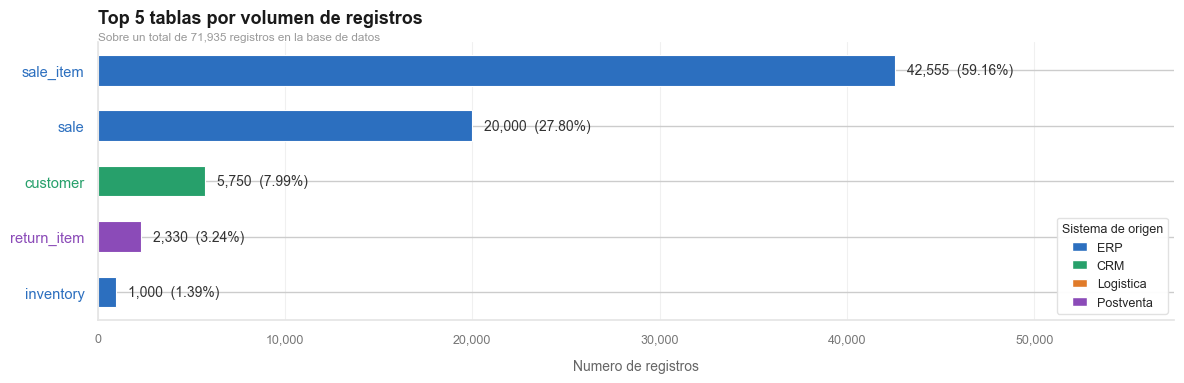

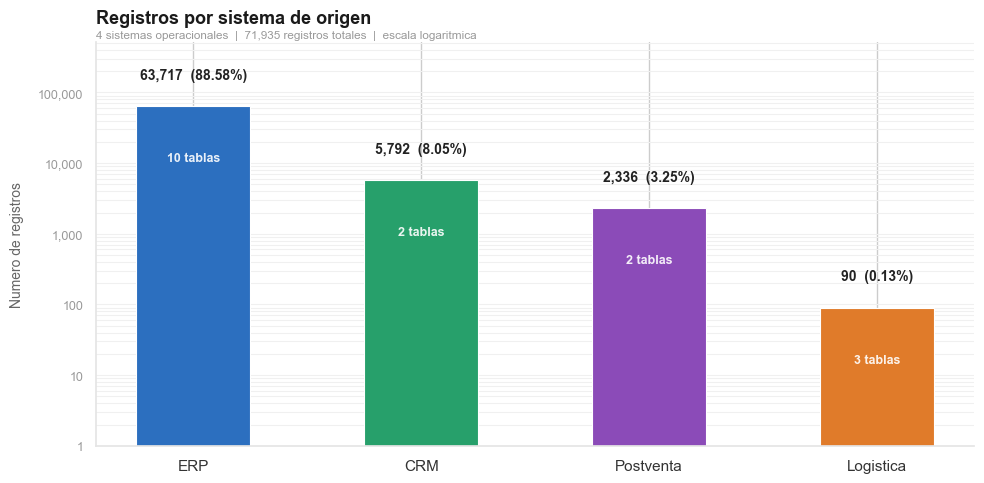


Seccion 1 completada - vision general de la base de datos establecida.


In [10]:
# ── Grafico 2a: Top 5 tablas por volumen ──────────────────────────────────────
color_por_tabla = {t: PALETA[s] for s, ts in SISTEMAS.items() for t in ts}
total_bd        = df_conteo['registros'].sum()

df_top5  = df_conteo.head(5).sort_values('registros', ascending=True)
colores5 = [color_por_tabla.get(t, '#AAAAAA') for t in df_top5['tabla']]

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('white')

bars = ax.barh(df_top5['tabla'], df_top5['registros'],
               color=colores5, edgecolor='white', linewidth=0.8, height=0.55)

max_v = df_top5['registros'].max()
for bar, val in zip(bars, df_top5['registros']):
    pct = val / total_bd * 100
    ax.text(bar.get_width() + max_v * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}  ({pct:.2f}%)',
            va='center', ha='left', fontsize=10,
            color='#333333', fontweight='500')

ax.set_title('Top 5 tablas por volumen de registros', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01, f'Sobre un total de {total_bd:,.0f} registros en la base de datos',
        transform=ax.transAxes, fontsize=8.5, color='#999999')

for label, tabla in zip(ax.get_yticklabels(), df_top5['tabla']):
    label.set_color(color_por_tabla.get(tabla, '#555555'))
    label.set_fontsize(10.5)

ax.set_xlabel('Numero de registros', fontsize=10, color='#666666', labelpad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', labelsize=9, colors='#777777')
ax.set_xlim(0, max_v * 1.35)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#F0F0F0', linewidth=0.8)

legend_elements = [Patch(facecolor=PALETA[s], label=s) for s in PALETA]
ax.legend(handles=legend_elements, title='Sistema de origen', title_fontsize=9,
          fontsize=9, loc='lower right', frameon=True,
          framealpha=0.95, edgecolor='#E0E0E0', handlelength=1.2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top5_tablas_volumen.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Grafico 2b: registros por sistema ────────────────────────────────────────
resumen_sistema = df_mapa.groupby('sistema')['registros'].sum().sort_values(ascending=False)
total_registros = resumen_sistema.sum()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')

sistemas  = resumen_sistema.index.tolist()
valores   = resumen_sistema.values.tolist()
colores_s = [PALETA[s] for s in sistemas]

bars2 = ax.bar(sistemas, valores, color=colores_s,
               edgecolor='white', linewidth=0.8, width=0.5)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(1, max(valores) * 8)

for bar, sistema, val in zip(bars2, sistemas, valores):
    pct   = val / total_registros * 100
    n_tab = len(SISTEMAS[sistema])
    # Valor + porcentaje encima de la barra
    ax.text(bar.get_x() + bar.get_width() / 2,
            val * 2.2,
            f'{val:,.0f}  ({pct:.2f}%)',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#222222')
    # Numero de tablas dentro de la barra
    ax.text(bar.get_x() + bar.get_width() / 2,
            val * 0.15,
            f'{n_tab} tabla{"s" if n_tab > 1 else ""}',
            ha='center', va='bottom', fontsize=9,
            color='white', fontweight='bold', alpha=0.9)

ax.set_title('Registros por sistema de origen', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01, f'4 sistemas operacionales  |  {total_registros:,.0f} registros totales  |  escala logaritmica',
        transform=ax.transAxes, fontsize=8.5, color='#999999')

ax.set_ylabel('Numero de registros', fontsize=10, color='#666666', labelpad=10)
ax.tick_params(axis='x', labelsize=11, colors='#333333')
ax.tick_params(axis='y', labelsize=9, colors='#999999')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#F0F0F0', linewidth=0.8, which='both')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distribucion_por_sistema.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print('\nSeccion 1 completada - vision general de la base de datos establecida.')